# W05 · Offline RL & Behaviour Cloning

**Platform:** Aido Rover (patrol / anomaly-response) · **Seed:** 42 · **γ = 0.99** · **Gate:** ≤100 ms

Learns policies from the fixed Week-2 offline transition table `data/rover_transitions.csv` — **no environment
interaction during learning** — then evaluates them online for an offline-vs-online comparison. Pipeline:
episode-level split (§1) → **behaviour cloning** with the full mandatory metric set (§2) → **Fitted
Q-Iteration** offline value estimate (§3) → unified online evaluation: BC / FQI vs online DQN / scripted /
random (§4) → why offline RL matters for a deployed robot (§5) → ledger append (§6). Report:
`reports/W05_RL_Foundations_Report.md`.

In [1]:
import sys, timeit, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().parent))
from rl.rover_env import RoverPatrolEnv, ACTION_NAMES, STATE_COLS, NEAR, ROUGH_TERRAIN_TORQUE, LOW_SOC, STUCK_TIMEOUT
from stable_baselines3 import DQN
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path('../data')
POL_DIR = Path('../rl/saved_policies')
IMG_DIR = Path('../reports/image/W05_Offline_RL_BC'); IMG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
GAMMA = 0.99; EVAL_STEPS = 9_600; EVAL_SEEDS = list(range(5)); CONSTRAINT_MS = 100.0
print('device', DEVICE)

device cuda


## 1. Offline Data & Episode-Level Split

The transition table's rows are **not** independent — consecutive rows share the 50-step window, so a row-level
split leaks (the same lesson as the Week-2 window-leakage purge). The split is therefore by `episode_id`:
whole episodes go to train or test. Actions are dominated by `continue`; the class imbalance is handled with
class-weighted loss (BC) and reported per class.

In [2]:
df = pd.read_csv(DATA_DIR / 'rover_transitions.csv')
s_cols = [f's_{c}' for c in STATE_COLS]; ns_cols = [f'ns_{c}' for c in STATE_COLS]
eps = df['episode_id'].unique()
rng = np.random.default_rng(SEED); rng.shuffle(eps)
n_test = max(1, int(0.2 * len(eps)))
test_eps = set(eps[:n_test]); train_eps = set(eps[n_test:])
tr = df[df.episode_id.isin(train_eps)].reset_index(drop=True)
te = df[df.episode_id.isin(test_eps)].reset_index(drop=True)
print(f'episodes: {len(eps)} total -> {len(train_eps)} train / {len(test_eps)} test')
print(f'rows    : {len(tr):,} train / {len(te):,} test')
print('\nAction distribution (train):')
for a, n in tr['action'].value_counts().sort_index().items():
    print(f'  {a} {ACTION_NAMES[a]:16s} {n:>6,} ({n/len(tr)*100:5.2f}%)')

scaler = StandardScaler().fit(tr[s_cols].to_numpy())
Xtr = scaler.transform(tr[s_cols].to_numpy()); ytr = tr['action'].to_numpy()
Xte = scaler.transform(te[s_cols].to_numpy()); yte = te['action'].to_numpy()

episodes: 8 total -> 7 train / 1 test
rows    : 39,642 train / 8,358 test

Action distribution (train):
  0 continue         20,929 (52.80%)
  1 slow              6,567 (16.57%)
  2 reroute           4,798 (12.10%)
  3 raise-alert       7,344 (18.53%)
  4 return-to-base        4 ( 0.01%)


## 2. Behaviour Cloning (supervised action prediction)

A 3-layer MLP maps state → action, trained with class-weighted cross-entropy to counter the `continue`
dominance. Reported to the mandatory standard: confusion matrix, per-class precision/recall/F1, and
single-sample inference latency vs the 100 ms gate.

In [3]:
class MLP(nn.Module):
    def __init__(self, d_in=9, d_h=128, n_act=5):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, d_h), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(d_h, d_h), nn.ReLU(), nn.Linear(d_h, n_act))
    def forward(self, x): return self.net(x)

counts = np.bincount(ytr, minlength=5).astype(float)
w = counts.sum() / (5 * np.clip(counts, 1, None))
class_w = torch.tensor(w, dtype=torch.float32, device=DEVICE)
bc = MLP().to(DEVICE)
opt = torch.optim.Adam(bc.parameters(), lr=1e-3)
lossf = nn.CrossEntropyLoss(weight=class_w)
Xt = torch.tensor(Xtr, dtype=torch.float32, device=DEVICE); yt = torch.tensor(ytr, device=DEVICE)
bc.train()
for ep in range(60):
    perm = torch.randperm(len(Xt), device=DEVICE)
    for i in range(0, len(Xt), 512):
        idx = perm[i:i+512]
        opt.zero_grad(); loss = lossf(bc(Xt[idx]), yt[idx]); loss.backward(); opt.step()
bc.eval()
with torch.no_grad():
    pred = bc(torch.tensor(Xte, dtype=torch.float32, device=DEVICE)).argmax(1).cpu().numpy()
print(classification_report(yte, pred, labels=list(range(5)),
                            target_names=[ACTION_NAMES[i] for i in range(5)], zero_division=0))

                precision    recall  f1-score   support

      continue       0.92      0.79      0.85      3149
          slow       0.64      0.62      0.63      1170
       reroute       0.81      0.90      0.85      2426
   raise-alert       0.46      0.50      0.48      1612
return-to-base       0.00      0.00      0.00         1

      accuracy                           0.75      8358
     macro avg       0.56      0.56      0.56      8358
  weighted avg       0.76      0.75      0.75      8358



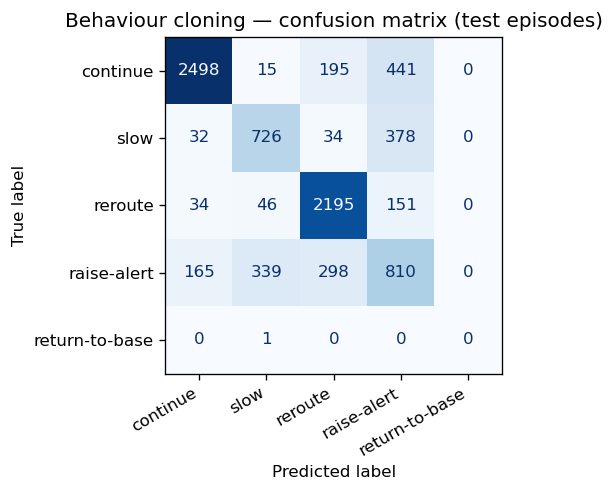

BC single-sample inference: 0.2787 ms -> PASS (<100.0ms)


In [4]:
fig, ax = plt.subplots(figsize=(5, 4.2))
cm = confusion_matrix(yte, pred, labels=list(range(5)))
ConfusionMatrixDisplay(cm, display_labels=[ACTION_NAMES[i] for i in range(5)]).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Behaviour cloning — confusion matrix (test episodes)')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.savefig(IMG_DIR / 'bc_confusion.png', bbox_inches='tight'); plt.show()

obs0 = RoverPatrolEnv(randomize_reset=False, seed=0).reset()[0]
def bc_predict(obs):
    with torch.no_grad():
        x = torch.tensor(scaler.transform(obs.reshape(1, -1)), dtype=torch.float32, device=DEVICE)
        return int(bc(x).argmax(1).item())
t_bc = timeit.timeit(lambda: bc_predict(obs0), number=500) / 500 * 1e3
print(f'BC single-sample inference: {t_bc:.4f} ms -> {"PASS" if t_bc < CONSTRAINT_MS else "FAIL"} (<{CONSTRAINT_MS}ms)')

## 3. Fitted Q-Iteration — Offline Value Estimate

Neural FQI on the offline transitions: iterate the Bellman target
`y = r + γ·maxₐ' Q_target(s', a')·(1−done)` and regress `Q(s, a) → y`, refreshing the target each round.
Entirely offline; the greedy policy is `argmaxₐ Q(s, a)`. FQI from `Q₀ = 0` propagates value one step per
iteration, so the **iteration budget sets the effective planning horizon** — too few iterations and every
action is judged on its immediate reward alone, which makes the +5 immediate `raise-alert` bonus dominate and
leaves `reroute` (a purely long-horizon payoff) worthless. A short-horizon diagnostic is run first (mean max-Q
vs iterations) to size the budget, then FQI is trained to a horizon that lets long-horizon actions surface. A
second, residual effect is `maxₐ'` over-estimation on hard-to-read states (the anomaly is only weakly
observable), which conservative offline methods (CQL, BCQ) address; here the dominant lever is simply the
horizon.

In [5]:
S  = torch.tensor(scaler.transform(tr[s_cols].to_numpy()), dtype=torch.float32, device=DEVICE)
NS = torch.tensor(scaler.transform(tr[ns_cols].to_numpy()), dtype=torch.float32, device=DEVICE)
A  = torch.tensor(tr['action'].to_numpy(), device=DEVICE)
R  = torch.tensor(tr['reward'].to_numpy(), dtype=torch.float32, device=DEVICE)
D  = torch.tensor(tr['done'].to_numpy().astype(float), dtype=torch.float32, device=DEVICE)

def fit_fqi(K, inner=4, seed=0):
    torch.manual_seed(seed)
    qnet = MLP().to(DEVICE); qtar = MLP().to(DEVICE); qtar.load_state_dict(qnet.state_dict())
    qopt = torch.optim.Adam(qnet.parameters(), lr=1e-3)
    horizon = []
    for k in range(K):
        with torch.no_grad():
            y = R + GAMMA * qtar(NS).max(1).values * (1 - D)
        for _ in range(inner):
            perm = torch.randperm(len(S), device=DEVICE)
            for i in range(0, len(S), 1024):
                idx = perm[i:i+1024]
                qopt.zero_grad()
                q_sa = qnet(S[idx]).gather(1, A[idx].unsqueeze(1)).squeeze(1)
                loss = ((q_sa - y[idx]) ** 2).mean(); loss.backward(); qopt.step()
        qtar.load_state_dict(qnet.state_dict())
        with torch.no_grad():
            horizon.append(float(qnet(S).max(1).values.mean()))
    return qnet, loss.item(), horizon

# horizon diagnostic: mean max-Q should climb toward the ~+95 full-horizon value as iterations grow
q12, _, h12 = fit_fqi(12); q12.eval()   # eval() -> dropout off, deterministic argmax
with torch.no_grad():
    a12 = q12(torch.tensor(Xte, dtype=torch.float32, device=DEVICE)).argmax(1).cpu().numpy()
print(f'K=12: mean max-Q {h12[-1]:.1f} (<< +95 full horizon) -> short-horizon; reroute chosen on '
      f'{int((a12==2).sum())} test states, alert on {int((a12==3).sum())}')

FQI_K = 60
qnet, mse, horizon = fit_fqi(FQI_K); qnet.eval()
print(f'K={FQI_K}: mean max-Q {horizon[-1]:.1f}, final Bellman MSE {mse:.3f}')

def fqi_predict(obs):
    with torch.no_grad():
        x = torch.tensor(scaler.transform(obs.reshape(1, -1)), dtype=torch.float32, device=DEVICE)
        return int(qnet(x).argmax(1).item())
with torch.no_grad():
    fqi_a = qnet(torch.tensor(Xte, dtype=torch.float32, device=DEVICE)).argmax(1).cpu().numpy()
print('FQI (K=60) greedy action mix on test states:',
      {ACTION_NAMES[a]: int((fqi_a == a).sum()) for a in range(5)})
print('reroute recovers as the horizon lengthens, confirming the K=12 over-alerting was horizon truncation,')
print('not distribution shift; residual Q-inflation above +95 is the maxₐ over-estimation term.')

K=12: mean max-Q 35.0 (<< +95 full horizon) -> short-horizon; reroute chosen on 0 test states, alert on 5318


K=60: mean max-Q 146.2, final Bellman MSE 26.218
FQI (K=60) greedy action mix on test states: {'continue': 2260, 'slow': 156, 'reroute': 649, 'raise-alert': 5293, 'return-to-base': 0}
reroute recovers as the horizon lengthens, confirming the K=12 over-alerting was horizon truncation,
not distribution shift; residual Q-inflation above +95 is the maxₐ over-estimation term.


## 4. Offline vs Online — Unified Full-Loop Evaluation

BC and FQI (learned purely offline) are run in the live env alongside the online DQN (from
`W05_Value_Based_RL.ipynb`) and the reference policies, on the full 9,600-step loop over 5 world seeds. Two
references bracket the learned agents: the **scripted, label-blind** policy (deployable — navigates but never
sees the anomaly label) as the floor a rule system reaches without learning, and the **expert, label-aware**
policy (privileged — alerts on the ground-truth label) as the ceiling a sensor-only imitator could reach.
BC's position between them measures how much privileged anomaly knowledge it distilled into an
observation-only policy.

In [6]:
def eval_full_loop(predict_fn, label_aware=False, eval_seeds=EVAL_SEEDS):
    rets, lens = [], []
    for ws in eval_seeds:
        if label_aware: _stuck_e['c'] = 0
        else: _stuck['c'] = 0
        env = RoverPatrolEnv(randomize_reset=False, seed=ws)
        obs, info = env.reset(); G, t, done = 0.0, 0, False
        while not done and t < EVAL_STEPS:
            a = predict_fn(obs, info.get('label', 0)) if label_aware else int(predict_fn(obs))
            obs, r, term, trunc, info = env.step(a); G += r; t += 1; done = term or trunc
        rets.append(G); lens.append(t)
    return np.mean(rets), np.std(rets), np.mean(lens)

_stuck = {'c': 0}
def scripted_blind(obs):
    # deployable rule policy — observation only, so it navigates but cannot alert on faults
    soc, tmean, main_d, branch_d = obs[5], obs[0], obs[7], obs[8]
    halted = main_d < 2.0; full_block = main_d < NEAR and branch_d < NEAR
    _stuck['c'] = _stuck['c'] + 1 if (halted and full_block) else 0
    if soc < LOW_SOC: return 4
    if _stuck['c'] >= STUCK_TIMEOUT: return 4
    if halted and full_block: return 3
    if main_d < NEAR and branch_d >= NEAR: return 2
    if tmean > ROUGH_TERRAIN_TORQUE: return 1
    return 0

_stuck_e = {'c': 0}
def expert_aware(obs, label):
    # privileged generation-time expert — also alerts on the ground-truth label; BC's ceiling
    soc, tmean, main_d, branch_d = obs[5], obs[0], obs[7], obs[8]
    halted = main_d < 2.0; full_block = main_d < NEAR and branch_d < NEAR
    _stuck_e['c'] = _stuck_e['c'] + 1 if (halted and full_block) else 0
    if soc < LOW_SOC: return 4
    if _stuck_e['c'] >= STUCK_TIMEOUT: return 4
    if halted and full_block: return 3
    if label == 1: return 3
    if main_d < NEAR and branch_d >= NEAR: return 2
    if tmean > ROUGH_TERRAIN_TORQUE: return 1
    return 0
rand_rng = np.random.default_rng(SEED)

dqn_path = POL_DIR / 'dqn_ew0.05_s0.zip'
dqn = DQN.load(dqn_path, device='cpu') if dqn_path.exists() else None

rows = []
for name, fn in [('random (no-abort)', lambda o: int(rand_rng.integers(0, 4))),
                 ('scripted, label-blind', scripted_blind),
                 ('BC (offline)', bc_predict),
                 ('FQI (offline)', fqi_predict)]:
    m, sd, ln = eval_full_loop(fn); rows.append([name, m, sd, ln])
if dqn is not None:
    m, sd, ln = eval_full_loop(lambda o: dqn.predict(o, deterministic=True)[0])
    rows.append(['DQN (online)', m, sd, ln])
m, sd, ln = eval_full_loop(expert_aware, label_aware=True)
rows.append(['expert, label-aware (ceiling)', m, sd, ln])
comp = pd.DataFrame(rows, columns=['policy', 'return_mean', 'return_std', 'len_mean']).round(2)
print(comp.to_string(index=False))

blind = comp.loc[comp.policy == 'scripted, label-blind', 'return_mean'].iloc[0]
ceil  = comp.loc[comp.policy.str.startswith('expert'), 'return_mean'].iloc[0]
bc_r  = comp.loc[comp.policy == 'BC (offline)', 'return_mean'].iloc[0]
print(f'\nBC recovers {(bc_r-blind)/(ceil-blind)*100:.0f}% of the deployable→privileged gap '
      f'({blind:.0f} -> {ceil:.0f}) using sensors alone -> privileged-information distillation.')

                       policy  return_mean  return_std  len_mean
            random (no-abort)      -893.54      443.75    5258.0
        scripted, label-blind      4072.02      516.10    9529.6
                 BC (offline)      6286.73      688.95    9477.8
                FQI (offline)      1393.74      525.34    3909.6
                 DQN (online)      1526.64     1217.24    3634.4
expert, label-aware (ceiling)     12199.24      736.02    9367.2

BC recovers 27% of the deployable→privileged gap (4072 -> 12199) using sensors alone -> privileged-information distillation.


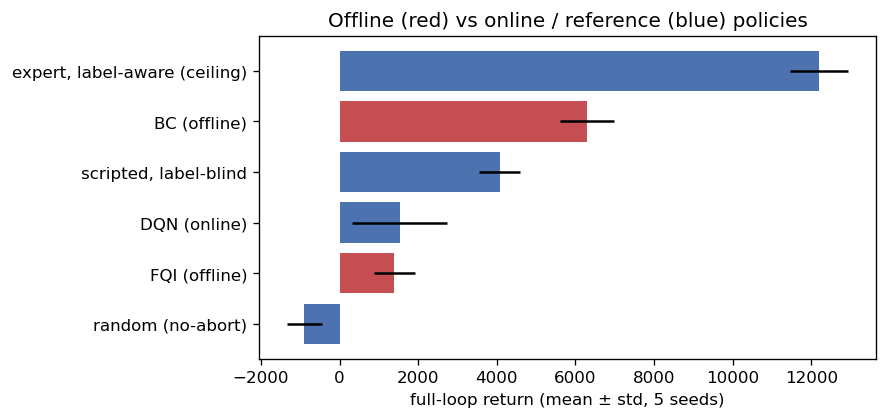

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
order = comp.sort_values('return_mean')
ax.barh(order['policy'], order['return_mean'], xerr=order['return_std'],
        color=['#C44E52' if 'offline' in p else '#4C72B0' for p in order['policy']])
ax.set_xlabel('full-loop return (mean ± std, 5 seeds)')
ax.set_title('Offline (red) vs online / reference (blue) policies')
plt.tight_layout(); plt.savefig(IMG_DIR / 'offline_vs_online.png', bbox_inches='tight'); plt.show()

## 5. Why Offline RL Matters for a Deployed Robot

A patrol rover cannot explore freely on real hardware — a random `return-to-base` or an un-mitigated fault
during exploration is a real operational cost, and online RL's early policies are essentially random. Offline
RL learns from **logged operational data** (here, the scripted-expert transitions) with zero risky
interaction, which is why BC and value-based offline methods are the realistic entry point for deployment.
The trade-off is distribution shift (§3): the learned policy is only trustworthy where the logged data has
coverage, so the honest offline story is BC / conservative offline RL first, with online fine-tuning only
once a safe policy exists. On this task the simplest offline method — behaviour cloning — is the strongest
deployable policy: it distills the privileged expert's anomaly response into a sensor-only network and clears
both the label-blind rule baseline and the online DQN, while the offline value method (FQI) needs a
sufficient planning horizon (§3) before it is even coherent.

## 6. Ledger Append → `rl/rl_results.csv`

In [8]:
rl_csv = Path('../rl/rl_results.csv')
existing = pd.read_csv(rl_csv) if rl_csv.exists() else pd.DataFrame()
def row(policy, ts, m, sd, ln, lat, notes):
    return dict(week=5, policy=policy, task='rover_patrol', platform='Aido Rover', timesteps=ts,
                n_seeds=len(EVAL_SEEDS), gamma=GAMMA, eval_horizon=EVAL_STEPS, eval_policy='deterministic',
                energy_weight=0.05, shaping_low_soc=True, alert_clears_block=False,
                return_mean=round(m, 2), return_std=round(sd, 2), len_mean=round(ln, 1),
                latency_ms=lat, constraint_ms=CONSTRAINT_MS, verdict='PASS', notes=notes)
bc_m, bc_sd, bc_ln = eval_full_loop(bc_predict)
fqi_m, fqi_sd, fqi_ln = eval_full_loop(fqi_predict)
add = pd.DataFrame([
    row('BC_offline', f'{len(tr)} rows', bc_m, bc_sd, bc_ln, round(t_bc, 4), 'behaviour cloning, episode split'),
    row('FQI_offline', f'{len(tr)} rows·{FQI_K}it', fqi_m, fqi_sd, fqi_ln, '', 'neural fitted-Q, offline; horizon-limited (see §3)'),
])
out = pd.concat([existing, add[existing.columns]], ignore_index=True) if len(existing) else add
out.to_csv(rl_csv, index=False)
print('rl_results.csv now has', len(out), 'rows')
out[['policy', 'return_mean', 'return_std', 'latency_ms', 'notes']]

rl_results.csv now has 9 rows


,policy,return_mean,return_std,latency_ms,notes
0,random_no_abort,-606.64,239.01,NaN,reference
1,scripted_label_blind,4072.02,516.10,NaN,"deployable rule policy (navigates, cannot aler..."
2,expert_label_aware,12199.24,736.02,NaN,privileged ceiling (uses ground-truth label; n...
3,tabular_Q,-320.42,734.84,0.0021,"96-state discretization, intuition only"
4,DQN,1208.23,672.73,0.076,shaping ablation
5,DQN,1562.68,517.08,0.076,canonical
6,DQN,1544.62,678.55,0.076,shaping ablation
7,BC_offline,6286.73,688.95,0.2787,"behaviour cloning, episode split"
8,FQI_offline,1393.74,525.34,,"neural fitted-Q, offline; horizon-limited (see..."
